# Create HAL config and shutter files

In [1]:
import os
import sys
from pathlib import Path
import numpy as np

MERCI_DIR  = Path(os.getcwd()).parent.parent.parent.parent  # MERci/ (notebook lives in MERci/notebooks/prepare_imaging/<variant>/<acquisition>/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root, e.g. LT048_sample_18/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs import (
    get_frame_table, get_transit_frame_table, get_color_sequence_name,
    create_shutter_file, create_hal_config, power_dict_to_channel_list,
    frame_table_filename, shutter_filename, hal_config_filename,
)
from MERci.acquisition.display import print_frame_table, display_xml
from MERci.visualization       import visualize_shutter_sequence

In [2]:
SETTINGS_DIR = SAMPLE_DIR / "settings"
METADATA_DIR = SAMPLE_DIR / "metadata"
SETTINGS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

MICROSCOPE = "MF4"

# ── Auto-detect HAL config template ────────────────────────────────────
# Looks for hal-config-*{MICROSCOPE}*.xml in MERci/data/configs/hal/
# (case-insensitive match on the microscope name)
_hal_dir        = MERCI_DIR / "data" / "configs" / "hal"
_hal_candidates = sorted(
    p for p in _hal_dir.glob("hal-config-*.xml")
    if MICROSCOPE.lower() in p.name.lower()
)
if not _hal_candidates:
    raise FileNotFoundError(
        f"No HAL template found for microscope '{MICROSCOPE}' in {_hal_dir}"
    )
HAL_TEMPLATE = _hal_candidates[0]

# ── Imaging file format and camera settings ────────────────────────────
# FILE_TYPE options: ".zarr" (default), ".dax", ".tiff"
FILE_TYPE     = ".zarr"
EXPOSURE_TIME = 0.25      # seconds

# ── Per-channel laser power ─────────────────────────────────────────────
# POWER maps each excitation wavelength (nm) to its laser power (0..1). It is
# applied two ways:
#   • written into every shutter <event>'s <power> (the actual per-frame
#     acquisition power), by frame colour;
#   • written into the HAL config <default_power> list, ordered per channel via
#     the microscope colour->channel map (power_dict_to_channel_list).
# Any wavelength not listed falls back to POWER_DEFAULT.
POWER = {
    750: 1.000,
    650: 0.500,
    560: 0.500,
    488: 0.010,
    405: 0.001,
}
POWER_DEFAULT = 1.0

print(f"SAMPLE_DIR   : {SAMPLE_DIR}")
print(f"SETTINGS_DIR : {SETTINGS_DIR}")
print(f"METADATA_DIR : {METADATA_DIR}")
print(f"HAL template : {HAL_TEMPLATE.name}")
print(f"Power (nm->power) : {POWER}")
print(f"HAL default_power : {power_dict_to_channel_list(POWER, MICROSCOPE, POWER_DEFAULT)}")

SAMPLE_DIR   : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time
SETTINGS_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings
METADATA_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\metadata
HAL template : hal-config-mf4-epi.xml
Power (nm->power) : {750: 1.0, 650: 0.5, 560: 0.5, 488: 0.01, 405: 0.001}
HAL default_power : [1.0, 0.5, 0.5, 0.01, 0.001]


## create hal config for bits

Color sequence name: blkf5_488f2_560f25_650f25_750f25
frames                  color                   channel                 z     

     0                     488                       3                    0.00
     1     2     3         750   650   560           0     1     2        1.00
     4     5     6         750   650   560           0     1     2        2.00
     7     8     9         750   650   560           0     1     2        3.00
    10    11    12         750   650   560           0     1     2        4.00
    13    14    15         750   650   560           0     1     2        5.00
    16    17    18         750   650   560           0     1     2        6.00
    19    20    21         750   650   560           0     1     2        7.00
    22    23    24         750   650   560           0     1     2        8.00
    25    26    27         750   650   560           0     1     2        9.00
    28    29    30         750   650   560           0     1     2       10.

HAL config saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\hal-config-mf4-bits-blkf5_488f2_560f25_650f25_750f25.xml


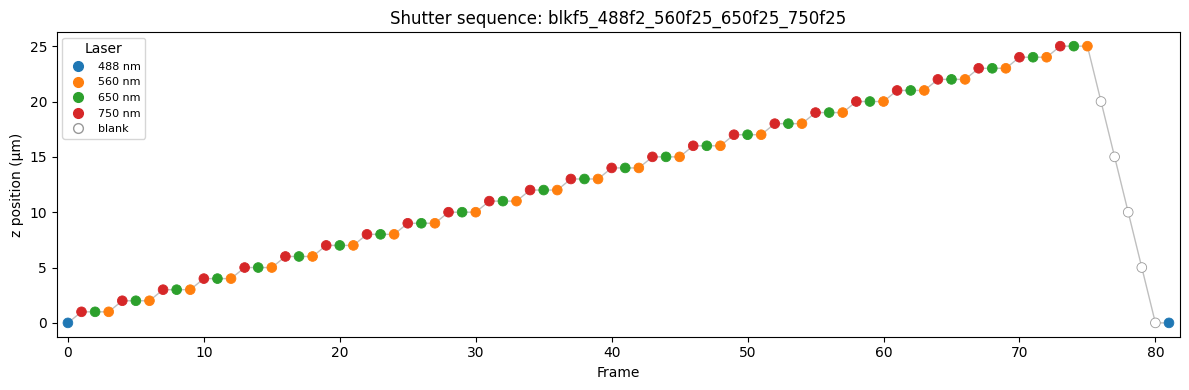

In [3]:
# ── Define imaging sequence ────────────────────────────────────────────
z_bead    = 0
z_min     = 1
z_max     = 25
z_step    = 1
z_pos     = np.arange(z_min, z_max+1, z_step) 
bead_seq  = [488]
color_seq = [750,    650,    560]
end_seq   = [488]

# Scan mode — controls the order in which z-planes and colors are acquired:
#   "interleaved" : all colors acquired at each Z-nanopositioner position before stepping to the next z
#                   (AOTF / fast electronic switching)
#   "sequential"  : full z-stack acquired per color with boustrophedon Z-nanopositioner sweep,
#                   then switch to the next color (physical shutter / slow switching)
SCAN_MODE = "interleaved"

# z return mode — how the objective travels back to z_bead after the stack:
#   "progressive" : blank frames step the objective down to z_bead in increments of RETURN_STEP
#   "instant"     : single jump back to z_bead (no intermediate frames)
Z_RETURN_MODE = "progressive"
RETURN_STEP   = 5


frame_table = get_frame_table(z_bead, bead_seq, color_seq, end_seq, z_pos,
                               microscope=MICROSCOPE, scan_mode=SCAN_MODE,
                               z_return_mode=Z_RETURN_MODE, return_step=RETURN_STEP)
name        = get_color_sequence_name(frame_table, scan_mode=SCAN_MODE)
print(f"Color sequence name: {name}")
print_frame_table(frame_table)

# ── Save frame table ────────────────────────────────────────────────────
ft_path = METADATA_DIR / frame_table_filename("bits", name)
frame_table.to_csv(ft_path)
print(f"Frame table saved: {ft_path}")

# ── Write shutter file (per-colour power from POWER) ─────────────────────
shutter_name = shutter_filename("bits", name)
shutter_path = SETTINGS_DIR / shutter_name
create_shutter_file(frame_table, shutter_path, default_power=POWER_DEFAULT, power=POWER)
print(f"Shutter file saved: {shutter_path}")
display_xml(shutter_path)

# ── Write HAL config (per-channel <default_power> from POWER) ────────────
hal_name   = hal_config_filename(MICROSCOPE, "bits", name)
hal_output = SETTINGS_DIR / hal_name
create_hal_config(HAL_TEMPLATE, frame_table, shutter_name, hal_output,
                  default_power=power_dict_to_channel_list(POWER, MICROSCOPE, POWER_DEFAULT),
                  file_type=FILE_TYPE, exposure_time=EXPOSURE_TIME)
print(f"HAL config saved: {hal_output}")
display_xml(hal_output)

# ── Visualise shutter sequence ──────────────────────────────────────────
visualize_shutter_sequence(
    frame_table,
    title=f"Shutter sequence: {name}",
    save_path=METADATA_DIR / f"shutter_sequence_{name}.png",
)

## create hal config for cells

Color sequence name: blkf5_405f25_488f2
frames           color     ch    z-range

0                488       3     0.00
1 - 25           405       4     1.00 -> 25.00  ^  (25 frames)
26 - 30          nan       nan   20.00 -> 0.00  v  (5 frames)
31               488       3     0.00
Frame table saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\metadata\frame-table-cells-blkf5_405f25_488f2.csv
Shutter file saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\shutter-cells-blkf5_405f25_488f2.xml


HAL config saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\hal-config-mf4-cells-blkf5_405f25_488f2.xml


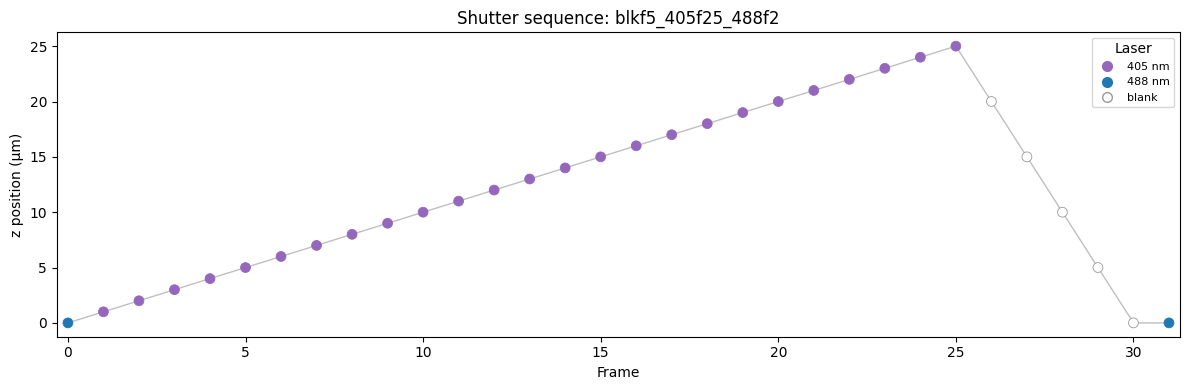

In [4]:
# ── Define imaging sequence ────────────────────────────────────────────
z_bead    = 0
z_min     = 1
z_max     = 25
z_step    = 1
z_pos     = np.arange(z_min, z_max+1, z_step) 
bead_seq  = [488]
color_seq = [405]
end_seq   = [488]

# Scan mode (see bits block for description; typically "interleaved" for a single-color round)
SCAN_MODE = "interleaved"

# z return mode — how the objective travels back to z_bead after the stack:
#   "progressive" : blank frames step the objective down to z_bead in increments of RETURN_STEP
#   "instant"     : single jump back to z_bead (no intermediate frames)
Z_RETURN_MODE = "progressive"
RETURN_STEP   = 5


frame_table = get_frame_table(z_bead, bead_seq, color_seq, end_seq, z_pos,
                               microscope=MICROSCOPE, scan_mode=SCAN_MODE,
                               z_return_mode=Z_RETURN_MODE, return_step=RETURN_STEP)
name        = get_color_sequence_name(frame_table, scan_mode=SCAN_MODE)
print(f"Color sequence name: {name}")
print_frame_table(frame_table)

# ── Save frame table ────────────────────────────────────────────────────
ft_path = METADATA_DIR / frame_table_filename("cells", name)
frame_table.to_csv(ft_path)
print(f"Frame table saved: {ft_path}")

# ── Write shutter file (per-colour power from POWER) ─────────────────────
shutter_name = shutter_filename("cells", name)
shutter_path = SETTINGS_DIR / shutter_name
create_shutter_file(frame_table, shutter_path, default_power=POWER_DEFAULT, power=POWER)
print(f"Shutter file saved: {shutter_path}")
display_xml(shutter_path)

# ── Write HAL config (per-channel <default_power> from POWER) ────────────
hal_name   = hal_config_filename(MICROSCOPE, "cells", name)
hal_output = SETTINGS_DIR / hal_name
create_hal_config(HAL_TEMPLATE, frame_table, shutter_name, hal_output,
                  default_power=power_dict_to_channel_list(POWER, MICROSCOPE, POWER_DEFAULT),
                  file_type=FILE_TYPE, exposure_time=EXPOSURE_TIME)
print(f"HAL config saved: {hal_output}")
display_xml(hal_output)

# ── Visualise shutter sequence ──────────────────────────────────────────
visualize_shutter_sequence(
    frame_table,
    title=f"Shutter sequence: {name}",
    save_path=METADATA_DIR / f"shutter_sequence_{name}.png",
)

## create hal config for transit

Transit FOVs sit between two tissue boundaries and are visited only to move the
stage smoothly between sections (see notebook 02). No data is collected there:
each transit FOV is imaged as `N_TRANSIT_BLANK` blank (laser-off) frames held at
the bead focus. This produces a dedicated `hal-config-{mic}-transit-*.xml` +
shutter that notebook 03 assigns to the transit movies.

In [5]:
# ── Define transit acquisition ─────────────────────────────────────────
z_bead          = 0     # bead focus; transit frames stay here
N_TRANSIT_BLANK = 2     # blank frames per transit FOV

transit_ft   = get_transit_frame_table(bead_z=z_bead, n_blank=N_TRANSIT_BLANK)
transit_name = get_color_sequence_name(transit_ft)   # e.g. "blkf2"
print(f"Transit sequence name: {transit_name}  ({N_TRANSIT_BLANK} blank frames)")
print_frame_table(transit_ft)

# ── Save frame table ────────────────────────────────────────────────────
ft_path = METADATA_DIR / frame_table_filename("transit", transit_name)
transit_ft.to_csv(ft_path)
print(f"Frame table saved: {ft_path}")

# ── Write shutter file (all frames blank -> no events) ───────────────────
shutter_name = shutter_filename("transit", transit_name)
shutter_path = SETTINGS_DIR / shutter_name
create_shutter_file(transit_ft, shutter_path)
print(f"Shutter file saved: {shutter_path}")
display_xml(shutter_path)

# ── Write HAL config ────────────────────────────────────────────────────
hal_name   = hal_config_filename(MICROSCOPE, "transit", transit_name)
hal_output = SETTINGS_DIR / hal_name
create_hal_config(HAL_TEMPLATE, transit_ft, shutter_name, hal_output,
                  default_power=power_dict_to_channel_list(POWER, MICROSCOPE, POWER_DEFAULT),
                  file_type=FILE_TYPE, exposure_time=EXPOSURE_TIME)
print(f"HAL config saved: {hal_output}")
display_xml(hal_output)

Transit sequence name: blkf2  (2 blank frames)
frames            color             channel           z     

     0     1         nan   nan         nan   nan        0.00
Frame table saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\metadata\frame-table-transit-blkf2.csv
Shutter file saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\shutter-transit-blkf2.xml


HAL config saved: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\settings\hal-config-mf4-transit-blkf2.xml
